In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\archive\tested.csv")
print(df)

     PassengerId  Survived  Pclass  \
0            892         0       3   
1            893         1       3   
2            894         0       2   
3            895         0       3   
4            896         1       3   
..           ...       ...     ...   
413         1305         0       3   
414         1306         1       1   
415         1307         0       3   
416         1308         0       3   
417         1309         0       3   

                                             Name     Sex   Age  SibSp  Parch  \
0                                Kelly, Mr. James    male  34.5      0      0   
1                Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                       Myles, Mr. Thomas Francis    male  62.0      0      0   
3                                Wirz, Mr. Albert    male  27.0      0      0   
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   
..                                            ...     ...

In [5]:
# Fill missing Age values with mean
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)

# Drop irrelevant columns
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

# Check cleaned dataset
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64


In [12]:
# Create age groups
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Survival rate by age group
age_group_survival = df.groupby('AgeGroup',observed=True)['Survived'].mean()

print(age_group_survival)

AgeGroup
Child          0.480000
Teen           0.444444
Young Adult    0.329365
Adult          0.393617
Senior         0.363636
Name: Survived, dtype: float64


In [13]:
#survival rate by Embarkation Port
embark_survival = df.groupby('Embarked')['Survived'].mean()
print(embark_survival)

Embarked
C    0.392157
Q    0.521739
S    0.325926
Name: Survived, dtype: float64


In [14]:
# Family Size = SibSp + Parch
df['FamilySize'] = df['SibSp'] + df['Parch']
#survival rate by Family Size
family_survival = df.groupby('FamilySize')['Survived'].mean()
print(family_survival)

FamilySize
0     0.268775
1     0.486486
2     0.526316
3     0.714286
4     0.285714
5     0.666667
6     0.250000
7     0.500000
10    0.500000
Name: Survived, dtype: float64


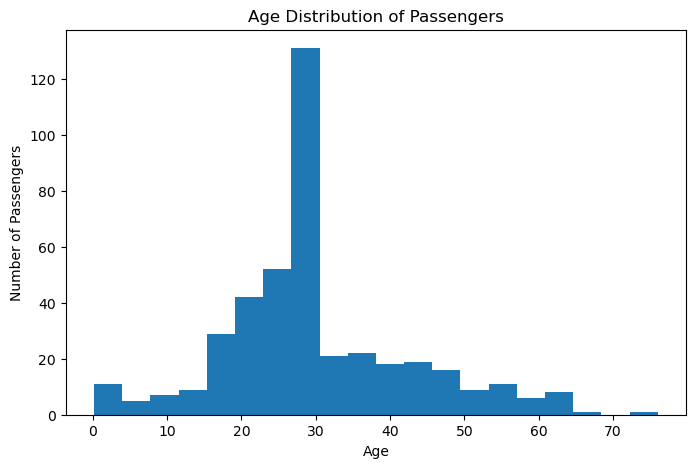

In [15]:
#Age distribution(histogram)
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

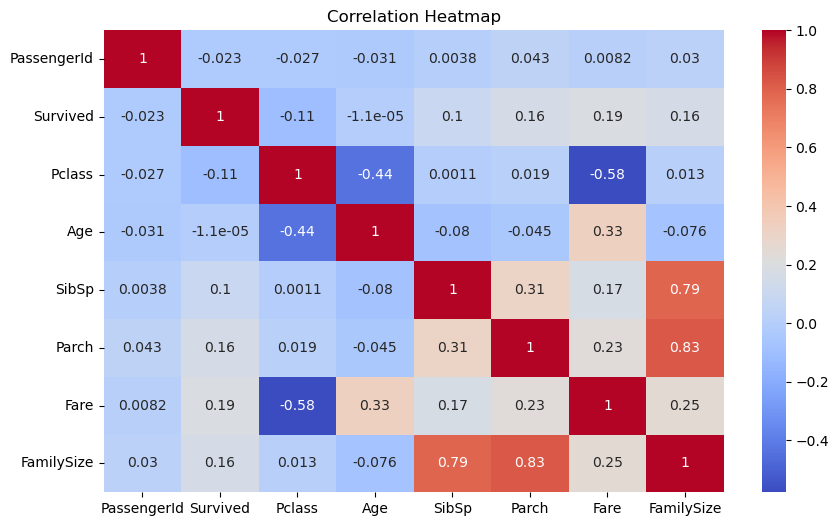

In [16]:
#Heatmap of correlations
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])
# Correlation matrix
corr = numeric_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

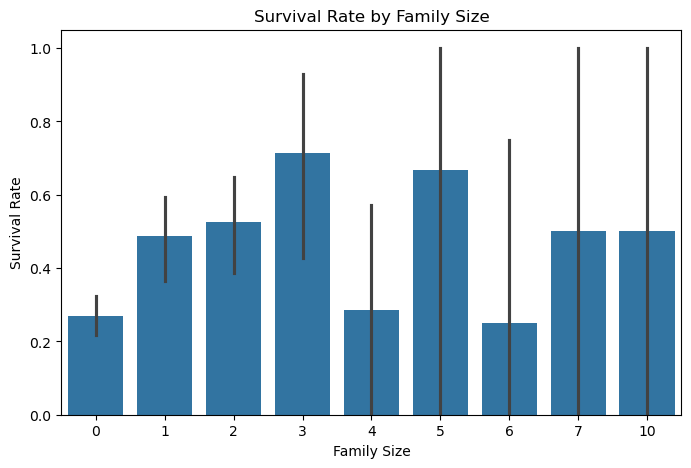

In [17]:
#survival by family size(bar plot)
plt.figure(figsize=(8,5))
sns.barplot(
    x='FamilySize',
    y='Survived',
    data=df
)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()